In [1]:
using FastGaussQuadrature, Beamlines, BeamTracking, BenchmarkTools, StaticArrays, GTPSA, SIMD, SIMDMathFunctions, Plots, LaTeXStrings, FFTW

In [2]:
const N = 48
x, wo = gausslegendre(N)
const t = SVector{N}((x .+ 1) ./ 2)
const w = SVector{N}(wo ./ 2)

48-element SVector{48, Float64} with indices SOneTo(48):
 0.0015766730261528293
 0.003663776950638136
 0.005738617289617284
 0.007789657861471924
 0.00980808022867776
 0.011785380419662185
 0.013713254854178491
 0.01558361391639905
 0.01738861128238518
 0.019120675532915344
 0.020772541471732346
 0.02233728042834715
 0.023808329246245225
 ⋮
 0.02233728042834715
 0.020772541471732346
 0.019120675532915344
 0.01738861128238518
 0.01558361391639905
 0.013713254854178491
 0.011785380419662185
 0.00980808022867776
 0.007789657861471924
 0.005738617289617284
 0.003663776950638136
 0.0015766730261528293

In [362]:
function __faddeeva_coeff(n, type::Type=Float64)
  N = n
  M = 2*N
  L = sqrt(N/sqrt(type(2)))
  theta_arr = [k*type(pi)/M for k in (-M+1):(M-1)]
  t_arr = L*tan.(theta_arr/2)
  f_arr = [(L^2 + t^2)*exp(-t^2) for t in t_arr]
  f_arr = vcat(zero(type), f_arr)
  a_arr = real.(fft(fftshift(f_arr)))/(2*M)
  return a_arr[2:(N+1)], L
end

@generated function faddeeva(z::Complex{T}, ::Val{N}) where {T,N}
  a_arr, L = __faddeeva_coeff(N, T)
  a_arr = reverse(a_arr)
  ex = :($(a_arr[1]))
  for i in 2:N
    ex = :(muladd($ex, Z, $(a_arr[i])))
  end
  return quote
    c1 = imag(z) >= 0 ? 0 : 1
    c2 = 1 - 2*c1
    z = c2*z
    lmiz_inv = 1/($L - im*z)
    Z = ($L + im*z)*lmiz_inv
    return c1*2*exp(-z^2) + c2*(2*$ex*lmiz_inv + $(1/sqrt(T(pi))))*lmiz_inv
  end
end


@inline function eval_poly(zr, zi, c, N)
    pr = c[1]
    pim = zero(zr)

    @inbounds for i in 2:N
        tmp = pr
        pr = muladd(pr, zr, -pim * zi) + c[i]
        pim = muladd(tmp, zi, pim * zr)
    end

    return pr, pim
end


@generated function faddeeva_sep(x::T, y::T, ::Val{N}) where {T,N}

    coeffs, L = __faddeeva_coeff(N, T)
    coeffs = reverse(coeffs)

    Lc = T(L)
    invsqrtpi = T(1/sqrt(pi))

    quote
        # ============================================================
        # branch flag (same as original complex code)
        # ============================================================
        xs = x
        ys = y

        # ============================================================
        # A = 1 / (L - i z)
        # denominator: (L + y)^2 + x^2
        # ============================================================
        d = $Lc + ys
        den = muladd(xs, xs, d*d)

        Ar = d / den
        Ai = xs / den

        # ============================================================
        # Z = (L + i z) / (L - i z)
        # numerator: (L - y + i x)
        # ============================================================
        Zr = ($Lc - ys) * Ar - xs * Ai
        Zi = ($Lc - ys) * Ai + xs * Ar

        # ============================================================
        # polynomial P(Z)
        # ============================================================
        pr, pim = eval_poly(Zr, Zi, $coeffs, N)

        # ============================================================
        # forward branch (exact translation of complex code)
        # ============================================================
        tr = 2*(pr*Ar - pim*Ai) + $invsqrtpi
        ti = 2*(pr*Ai + pim*Ar)

        wr_pos = tr*Ar - ti*Ai
        wi_pos = tr*Ai + ti*Ar

        # ============================================================
        # reflection branch: 2 e^{-z^2} - w(z)
        # ============================================================
        ex = exp(-(xs*xs - ys*ys))
        ang = -2*xs*ys

        wr_ref = 2*ex*cos(ang) - wr_pos
        wi_ref = 2*ex*sin(ang) - wi_pos

        # ============================================================
        # select (GPU-safe, no blending)
        # ============================================================
        wr = vifelse((y < zero(T)) & (abs(y) > eps(T)*2), wr_ref, wr_pos)
        wi = vifelse((y < zero(T)) & (abs(y) > eps(T)*2), wi_ref, wi_pos)

        return wr, wi
    end
end

@generated function faddeeva_sep(x::SIMD.Vec{N,T}, y::SIMD.Vec{N,T}, ::Val{M}) where {T,N,M}

    coeffs, L = __faddeeva_coeff(M, T)
    coeffs = reverse(coeffs)

    Lc = T(L)
    invsqrtpi = T(1/sqrt(pi))

    quote
        # ============================================================
        # branch flag (same as original complex code)
        # ============================================================
        xs = x
        ys = y

        # ============================================================
        # A = 1 / (L - i z)
        # denominator: (L + y)^2 + x^2
        # ============================================================
        d = $Lc + ys
        den = muladd(xs, xs, d*d)

        Ar = d / den
        Ai = xs / den

        # ============================================================
        # Z = (L + i z) / (L - i z)
        # numerator: (L - y + i x)
        # ============================================================
        Zr = ($Lc - ys) * Ar - xs * Ai
        Zi = ($Lc - ys) * Ai + xs * Ar

        # ============================================================
        # polynomial P(Z)
        # ============================================================
        pr, pim = eval_poly(Zr, Zi, $coeffs, M)

        # ============================================================
        # forward branch (exact translation of complex code)
        # ============================================================
        tr = 2*(pr*Ar - pim*Ai) + $invsqrtpi
        ti = 2*(pr*Ai + pim*Ar)

        wr_pos = tr*Ar - ti*Ai
        wi_pos = tr*Ai + ti*Ar

        # ============================================================
        # reflection branch: 2 e^{-z^2} - w(z)
        # ============================================================
        ex = exp(-(xs*xs - ys*ys))
        ang = -2*xs*ys

        wr_ref = 2*ex*cos(ang) - wr_pos
        wi_ref = 2*ex*sin(ang) - wi_pos

        # ============================================================
        # select (GPU-safe, no blending)
        # ============================================================
        wr = vifelse((y < zero(T)) & (abs(y) > eps(T)*2), wr_ref, wr_pos)
        wi = vifelse((y < zero(T)) & (abs(y) > eps(T)*2), wi_ref, wi_pos)

        return wr, wi
    end
end

faddeeva_sep (generic function with 2 methods)

In [352]:
const bx = 80e-2
const by = 7e-2
const ex = 11.3e-9
const ey = 1e-9
const sz = 6e-2
const Q = 0.688e11*BeamTracking.E_CHARGE
const k = 1/(4*pi*BeamTracking.EPS_0)
const C_LIGHT = BeamTracking.C_LIGHT

2.99792458e8

In [353]:
function I(x, y; sx2, sy2)
    result = zero(x)
    x2 = x*x
    y2 = y*y
    sx2_star = bx*ex
    it = 1 .- t
    it_inv = 1 ./ it
    it_inv2 = it_inv .* it_inv
    xis = sx2 .* t .* it_inv
    as = sx2 .+ xis
    bs = sy2 .+ xis
    fun_coeff = sx2 .* it_inv2
    @inbounds for i in 1:N
        ti = t[i]
        iti = it[i]
        iti_inv = it_inv[i]
        iti_inv2 = it_inv2[i]
        xi = xis[i]
        a = as[i]
        b = bs[i]
        first = exp(-x2/(2*a) - y2/(2*b))/sqrt(a*b)
        second = 1/(sx2_star + xi)
        fun = fun_coeff[i]*(first - second)
        result += w[i] * fun
    end
    return result
end

I (generic function with 1 method)

In [354]:
@btime I($(sqrt(bx*ex)),$0.0; sx2=$(bx*ex), sy2=$(by*ey))

  243.972 ns (0 allocations: 0 bytes)


0.4283033234077576

In [438]:
@inline w_f(z) = faddeeva(z, Val(48))

function be(x, y; sx2, sy2)
    sq = sqrt(2*(sx2-sy2))
    dens = exp(-x*x/(2*sx2) - y*y/(2*sy2))
    arg1 = (x+1im*y)/sq
    w1 = w_f(arg1)
    r = sqrt(sx2/sy2)
    arg2 = (x/r+1im*y*r)/sq
    w2 = w_f(arg2)
    result = w1 - dens*w2
    wp1 = 2im/sqrt(pi) - 2*arg1*w1
    wp2 = 2im/sqrt(pi) - 2*arg2*w2
    result2x = imag(wp1/sq + x/sx2*dens*w2 - dens*wp2/(r*sq))
    result2y = real(1im*wp1/sq + y/sy2*dens*w2 - 1im*r*dens*wp2/sq)
    return real(result), imag(result), result2x, result2y
end

be (generic function with 1 method)

In [439]:
w_f(0.0, 1e-5)

(0.9999887163083281, 0.0)

In [440]:
erfcx(1e-5)

0.999988716308329

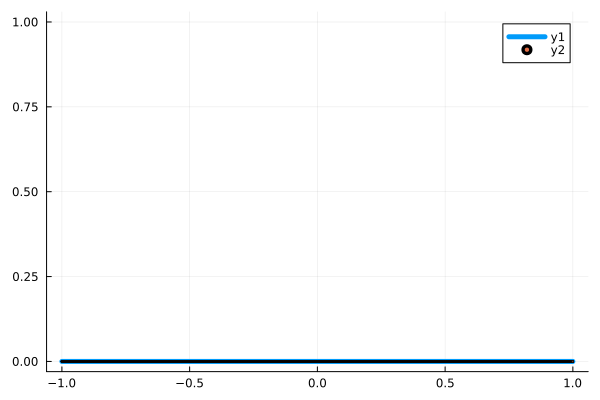

In [441]:
xs = range(-1, 1, length=10000)
plot(xs, [imag(erfcx(x)) for x in xs], linewidth=5)
scatter!(xs, [imag(faddeeva(im*x, Val(48))) for x in xs], markersize=1)

In [442]:
erfcx(0.1)
#arg1_x = 0.7100284591509088
#arg2_x = 0.15476704900540109

0.8964569799691268

In [443]:
be(0.2, 0.0; sx2=0.2^2, sy2=0.1^2)

(3.3306690738754696e-16, 0.35264712928698755, 0.8585891683331941, 3.332466719780891)

In [444]:
function bb_potential(x, y, s, t, p)
    L = p
    sx2 = ex * (bx + (s-L/2)^2/bx)
    sy2 = ey * (by + (s-L/2)^2/by)
    phi_slice = k*Q*I(x, y; sx2, sy2)
    dens = exp(-(s - L + C_LIGHT*t)^2/(2*sz^2))/(sqrt(2*pi)*sz)
    phi = phi_slice*dens
    As = -phi/C_LIGHT
    dphi_dt = -C_LIGHT/sz^2*(s - L + C_LIGHT*t)*phi
    dAs_dt = -dphi_dt/C_LIGHT
    dsx_ds = ex/bx*(s-L/2)/sqrt(sx2)
    dsy_ds = ey/by*(s-L/2)/sqrt(sy2)
    factor = -2*pi*k*Q/sqrt(2*pi*(sx2-sy2))
    re, im, xp, yp = be(x, y; sx2, sy2)
    dphi_dsx = sqrt(sx2)*factor*xp 
    dphi_dsy = sqrt(sy2)*factor*yp
    dphi_ds = dphi_dt/C_LIGHT + (dphi_dsx*dsx_ds + dphi_dsy*dsy_ds)*dens
    dAs_ds = -dphi_ds/C_LIGHT
    dphi_dx = factor*dens*im
    dphi_dy = factor*dens*re
    dAs_dx = -dphi_dx/C_LIGHT
    dAs_dy = -dphi_dy/C_LIGHT
    zer = zero(phi)
    pot = (phi, zer, zer, As)
    jac = (dphi_dx, dphi_dy, dphi_ds, dphi_dt,
           zer,     zer,     zer,     zer,
           zer,     zer,     zer,     zer,
           dAs_dx, dAs_dy, dAs_ds, dAs_dt)
    return pot, jac
end

bb_potential (generic function with 1 method)

In [445]:
ele = LineElement(four_potential = bb_potential, four_potential_normalized = false, four_potential_params = 1.0, L = 1.0, tracking_method = Yoshida(order=2, n_steps=20))
patch_in = Patch(dy_rot = 0*-25e-3)
patch_out = Patch(dy_rot = 0*25e-3)
bl = Beamline([patch_in, ele, patch_out], species_ref = Species("electron"), E_ref = 18e9)

Beamline:
 species_ref = electron
 E_ref = 1.8e10

  Index   Name   Kind    s [m] 
  1              Patch   0
  2                      0.0f0
  3              Patch   1.0


In [446]:
b0 = Bunch([sqrt(bx*ex) 0.0 sqrt(by*ey) 0.0 0.0 0.0], p_over_q_ref=bl.p_over_q_ref, species=Species("electron"))
track!(b0,bl)
b0.coords.v[1:6]

6-element Vector{Float64}:
  5.748017571123983e-5
 -7.519329378052836e-5
 -1.6904059535361774e-5
 -5.0324705449361905e-5
 -1.9880861338066453e-9
  2.0461408392032635e-9

In [464]:
xs = range(-10*sqrt(ex*bx), 10*sqrt(ex*bx), length=1001)
finals = zeros(1001)
i = 1
for x in xs
    b0 = Bunch([x 0.0 0.0 0.0 0.0 0.0], p_over_q_ref=bl.p_over_q_ref, species=Species("electron"))
    track!(b0,bl);
    finals[i] = b0.coords.v[2]
    i += 1
end

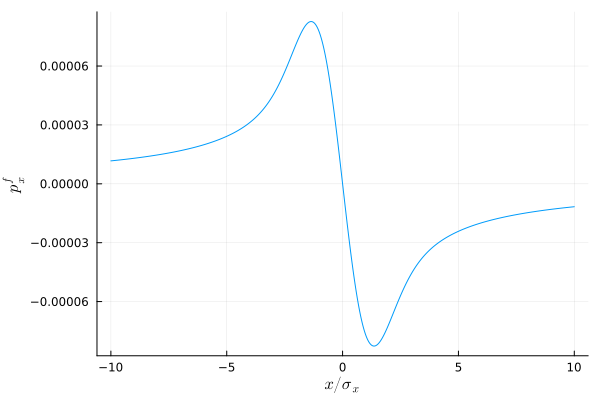

In [465]:
plot(xs/sqrt(ex*bx), finals, xlabel=L"$x/\sigma_x$", ylabel=L"$p_x^f$", legend=false)
#savefig("/Users/josephdevlin/Downloads/be.pdf")